# 手写数字识别（MNIST）大作业

## 1. 导入所有需要的库

In [1]:
# ==================== 基础库 ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 机器学习库 ====================
from sklearn.datasets import fetch_openml           # 下载 MNIST 数据集
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# ==================== 三个模型 ====================
from sklearn.svm import SVC                          # 模型1：支持向量机
from sklearn.ensemble import RandomForestClassifier  # 模型2：随机森林
from sklearn.neural_network import MLPClassifier     # 模型3：多层感知机（神经网络）

# ==================== 数据增强用 ====================
from scipy.ndimage import rotate, shift              # 旋转、平移图片

# ==================== 画图设置 ====================
# 使用 Noto Sans CJK SC 支持中文显示（系统已安装）
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print("所有库导入成功！")

所有库导入成功！


## 2.加载 MNIST 数据集

- 训练集 60000 张
- 测试集 10000 张

In [2]:
print("正在加载 MNIST 数据集...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
print(f"加载完成！")

# 看一下数据长什么样
print(f"特征矩阵 X 的形状: {X.shape}")   # 应该是 (70000, 784)
print(f"标签向量 y 的形状: {y.shape}")   # 应该是 (70000,)
print(f"标签的数据类型: {y.dtype}")       # 应该是 object（字符串）
print(f"前 10 个标签: {y[:10]}")         # 看看标签长什么样

正在加载 MNIST 数据集...
加载完成！
特征矩阵 X 的形状: (70000, 784)
标签向量 y 的形状: (70000,)
标签的数据类型: object
前 10 个标签: ['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']


### 2.1 类型转换

`fetch_openml` 返回的标签是**字符串**（'0'、'1'...），我们需要转成整数。像素值是 0-255 的整数，归一化之前先转成 float32。

In [3]:
# 标签：字符串 → 整数
y = y.astype(np.int32)

# 像素：整数 → float32（为归一化作准备），然后除以 255 缩放到 [0, 1]
X = X.astype(np.float32) / 255.0

print(f"标签类型: {y.dtype}, 范围: {y.min()} ~ {y.max()}")
print(f"像素类型: {X.dtype}, 范围: {X.min():.4f} ~ {X.max():.4f}")

标签类型: int32, 范围: 0 ~ 9
像素类型: float32, 范围: 0.0000 ~ 1.0000


### 2.2 划分训练集和测试集

MNIST 的 70000 张图，前 60000 张是训练集，后 10000 张是测试集。

In [4]:
X_train_full, X_test = X[:60000], X[60000:]
y_train_full, y_test = y[:60000], y[60000:]

print(f"训练集: {X_train_full.shape[0]} 张图片")
print(f"测试集: {X_test.shape[0]} 张图片")

# 对每个类别计数，看分布是否均衡
unique, counts = np.unique(y_train_full, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  数字 {u}: {c:5d} 张 ({c/len(y_train_full)*100:.1f}%)")

训练集: 60000 张图片
测试集: 10000 张图片
  数字 0:  5923 张 (9.9%)
  数字 1:  6742 张 (11.2%)
  数字 2:  5958 张 (9.9%)
  数字 3:  6131 张 (10.2%)
  数字 4:  5842 张 (9.7%)
  数字 5:  5421 张 (9.0%)
  数字 6:  5918 张 (9.9%)
  数字 7:  6265 张 (10.4%)
  数字 8:  5851 张 (9.8%)
  数字 9:  5949 张 (9.9%)


### 2.3 看看数据长什么样

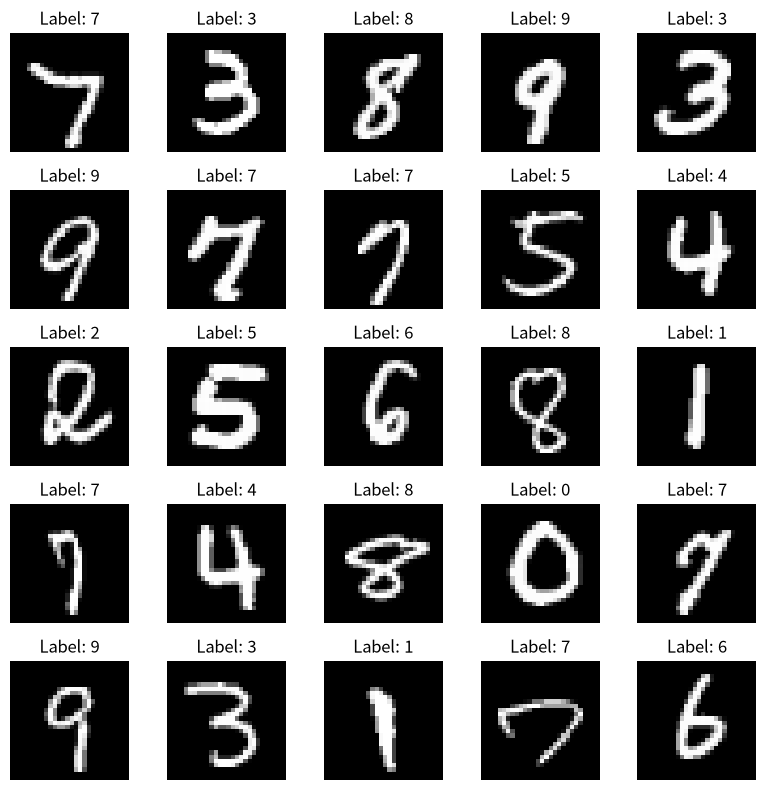

In [5]:
# 随机选 25 张图展示
np.random.seed(42)
indices = np.random.choice(len(X_train_full), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = X_train_full[indices[i]].reshape(28, 28)   # 784 → 28×28
    label = y_train_full[indices[i]]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. 加载手工采集数据集

### 3.1 手工数据情况

- 在纸上手写 0-9，每个数字 6 个样本，共 60 张照片
- 手机拍摄，原图 3456×3456 RGB
- 通过 `preprocess_augment.py` 处理成 28×28 灰度图（黑底白字，MNIST 格式）
- 存放于 `手写数据_处理后/01_原始处理后/`

### 3.2 标签说明

按照文件名生成标签 xx-y.jpg

手工数据集: 60 张, 特征维度 784
标签分布: [6 6 6 6 6 6 6 6 6 6]


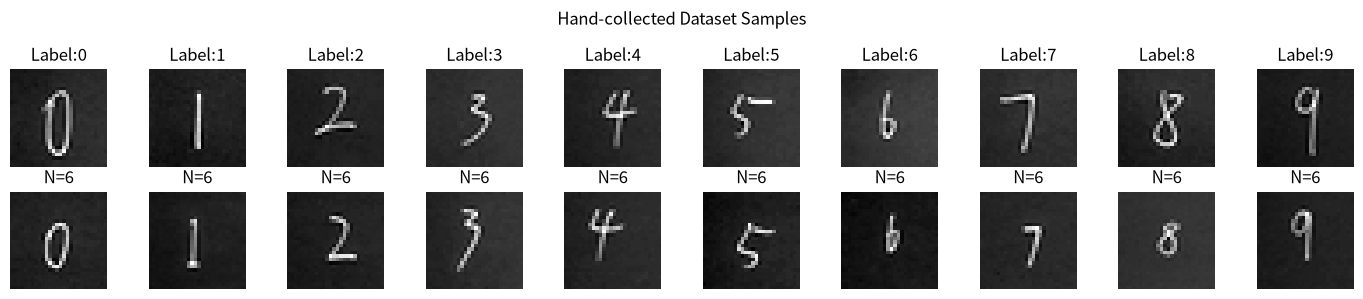

In [6]:
import os
import re
from PIL import Image

HAND_DATA_DIR = "/home/shorin/Projects/Py/大作业/手写数据_处理后/01_原始处理后"

# 读取所有 28×28 处理后图片，从文件名 xx-y.png 中解析标签
hand_files = sorted(os.listdir(HAND_DATA_DIR))
hand_images = []
hand_labels = []

for fname in hand_files:
    img = Image.open(os.path.join(HAND_DATA_DIR, fname))
    arr = np.array(img, dtype=np.float32)
    # 归一化到 [0,1]（与 MNIST 一致）
    arr = arr / 255.0
    hand_images.append(arr.flatten())  # 拉平成 784 维
    # 从文件名解析标签: "01-5.png" → 数字 5
    label = int(re.search(r'-(\d)\.', fname).group(1))
    hand_labels.append(label)

X_hand = np.array(hand_images)
y_hand = np.array(hand_labels, dtype=np.int32)

print(f"手工数据集: {X_hand.shape[0]} 张, 特征维度 {X_hand.shape[1]}")
print(f"标签分布: {np.bincount(y_hand)}")

# 展示手工数据（按真实标签分组，每个数字展示 2 个样本）
hand_by_label = {d: [] for d in range(10)}
for i, lbl in enumerate(y_hand):
    hand_by_label[lbl].append(i)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    samples = hand_by_label[digit]
    # 取第 1 个和第 min(4, len) 个样本
    idx1 = samples[0]
    idx2 = samples[min(3, len(samples)-1)]
    axes[0, digit].imshow(hand_images[idx1].reshape(28, 28), cmap='gray')
    axes[0, digit].set_title(f"Label:{digit}")
    axes[0, digit].axis('off')
    axes[1, digit].imshow(hand_images[idx2].reshape(28, 28), cmap='gray')
    axes[1, digit].set_title(f"N={len(samples)}")
    axes[1, digit].axis('off')
plt.suptitle("Hand-collected Dataset Samples", fontsize=12)
plt.tight_layout()
plt.savefig("/home/shorin/Projects/Py/大作业/手工数据展示.png", dpi=120, bbox_inches='tight')
plt.show()

## 4. 数据增强（MNIST 训练集增强）
对 MNIST 训练集做旋转、平移、噪声增强，扩充 25000 张作为额外训练数据。

开始增强 25000 张图片...
  已完成 5000/25000...
  已完成 10000/25000...
  已完成 15000/25000...
  已完成 20000/25000...
  已完成 25000/25000...
增强完成！增强数据集: (25000, 784)
合并增强后训练集: 85000 张 (原始 60000 + 增强 25000)


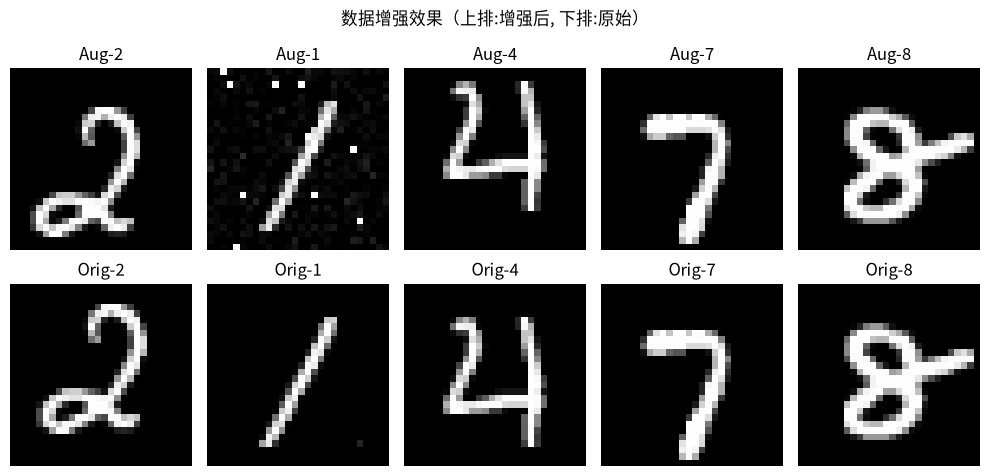

In [7]:
from scipy.ndimage import rotate, shift

def augment_image(img_flat):
    """
    对单张 784 维图片做随机增强，返回增强后的 784 维向量。
    img_flat 需要先 reshape 成 (28, 28)。
    """
    img = img_flat.reshape(28, 28)
    aug_type = np.random.choice(['rotate', 'shift', 'noise', 'none'])
    
    if aug_type == 'rotate':
        angle = np.random.uniform(-15, 15)
        img = rotate(img, angle, reshape=False, mode='nearest')
    elif aug_type == 'shift':
        dx = np.random.randint(-3, 4)
        dy = np.random.randint(-3, 4)
        img = shift(img, shift=(dy, dx), mode='nearest')
    elif aug_type == 'noise':
        noise = np.random.normal(0, 0.05, img.shape)
        img = img + noise
        # 椒盐噪声
        prob = 0.02
        rand = np.random.random(img.shape)
        img[rand < prob/2] = 0
        img[rand > 1 - prob/2] = 1.0
    
    return np.clip(img, 0, 1).flatten()

# 从训练集中随机选 25000 张做增强
np.random.seed(42)
n_augment = 25000
aug_indices = np.random.choice(len(X_train_full), n_augment, replace=True)

X_augmented = np.zeros((n_augment, 784), dtype=np.float32)
y_augmented = np.zeros(n_augment, dtype=np.int32)

print(f"开始增强 {n_augment} 张图片...")
for i in range(n_augment):
    idx = aug_indices[i]
    X_augmented[i] = augment_image(X_train_full[idx])
    y_augmented[i] = y_train_full[idx]
    if (i + 1) % 5000 == 0:
        print(f"  已完成 {i+1}/{n_augment}...")

print(f"增强完成！增强数据集: {X_augmented.shape}")

# ======== 合并训练集 ========
X_train_enhanced = np.vstack([X_train_full, X_augmented])
y_train_enhanced = np.concatenate([y_train_full, y_augmented])

print(f"合并增强后训练集: {X_train_enhanced.shape[0]} 张 "
      f"(原始 {X_train_full.shape[0]} + 增强 {n_augment})")

# 展示增强效果
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
sample_idx = np.random.choice(len(X_augmented), 5, replace=False)
for i, (ax, si) in enumerate(zip(axes[0], sample_idx)):
    ax.imshow(X_augmented[si].reshape(28, 28), cmap='gray')
    ax.set_title(f"Aug-{y_augmented[si]}")
    ax.axis('off')
for i, (ax, si) in enumerate(zip(axes[1], sample_idx)):
    orig_idx = aug_indices[si]
    ax.imshow(X_train_full[orig_idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Orig-{y_train_full[orig_idx]}")
    ax.axis('off')
plt.suptitle("数据增强效果（上排:增强后, 下排:原始）")
plt.tight_layout()
plt.savefig("/home/shorin/Projects/Py/大作业/增强效果展示.png", dpi=120, bbox_inches='tight')
plt.show()

## 5. 数据预处理检查

### 5.1 缺失值检查

In [8]:
# ======== 缺失值检查 ========
print("=== 缺失值检查 ===")
print(f"MNIST 训练集: NaN 数量 = {np.isnan(X_train_full).sum()}, Inf 数量 = {np.isinf(X_train_full).sum()}")
print(f"MNIST 测试集: NaN 数量 = {np.isnan(X_test).sum()}, Inf 数量 = {np.isinf(X_test).sum()}")
print(f"增强数据集:   NaN 数量 = {np.isnan(X_augmented).sum()}, Inf 数量 = {np.isinf(X_augmented).sum()}")
print(f"手工数据集:   NaN 数量 = {np.isnan(X_hand).sum()}, Inf 数量 = {np.isinf(X_hand).sum()}")
print("结论: 所有数据集均无缺失值 ✓")

# ======== 异常值检查 ========
print("\n=== 异常值检查（像素值应在 [0, 1] 范围内）===")
for name, data in [("MNIST训练集", X_train_full), ("MNIST测试集", X_test),
                    ("增强数据集", X_augmented), ("手工数据集", X_hand)]:
    print(f"{name}: min={data.min():.4f}, max={data.max():.4f}")
print("结论: 所有像素值均在 [0, 1] 范围内 ✓")

# ======== 标签检查 ========
print("\n=== 标签范围检查 ===")
print(f"MNIST 训练集标签: {y_train_full.min()} ~ {y_train_full.max()}")
print(f"MNIST 测试集标签: {y_test.min()} ~ {y_test.max()}")
print(f"手工数据集标签:   {y_hand.min()} ~ {y_hand.max()}")

=== 缺失值检查 ===
MNIST 训练集: NaN 数量 = 0, Inf 数量 = 0
MNIST 测试集: NaN 数量 = 0, Inf 数量 = 0
增强数据集:   NaN 数量 = 0, Inf 数量 = 0
手工数据集:   NaN 数量 = 0, Inf 数量 = 0
结论: 所有数据集均无缺失值 ✓

=== 异常值检查（像素值应在 [0, 1] 范围内）===
MNIST训练集: min=0.0000, max=1.0000
MNIST测试集: min=0.0000, max=1.0000
增强数据集: min=0.0000, max=1.0000
手工数据集: min=0.0000, max=1.0000
结论: 所有像素值均在 [0, 1] 范围内 ✓

=== 标签范围检查 ===
MNIST 训练集标签: 0 ~ 9
MNIST 测试集标签: 0 ~ 9
手工数据集标签:   0 ~ 9


## 6. 划分训练集 / 验证集 / 测试集

从 MNIST 原始训练集（60000）中分出 80% 作为训练、20% 作为验证。增强数据只加入训练集。

In [9]:
# 1. 从原始训练集分出训练/验证
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# 2. 训练集合并增强数据
X_train = np.vstack([X_train_raw, X_augmented])
y_train = np.concatenate([y_train_raw, y_augmented])

# 3. 测试集 = MNIST 测试集 + 手工数据集
X_test_combined = np.vstack([X_test, X_hand])
y_test_combined = np.concatenate([y_test, y_hand])

print(f"训练集 (原始+增强): {X_train.shape[0]} 张 - {X_train_raw.shape[0]} 原始 + {X_augmented.shape[0]} 增强")
print(f"验证集:              {X_val.shape[0]} 张")
print(f"测试集 (MNIST+手工):  {X_test_combined.shape[0]} 张 - {X_test.shape[0]} MNIST + {X_hand.shape[0]} 手工")

# 检查分布
print("\n训练集各类别分布:")
for d, c in zip(*np.unique(y_train, return_counts=True)):
    print(f"  数字 {d}: {c:6d} 张")

print("\n验证集各类别分布:")
for d, c in zip(*np.unique(y_val, return_counts=True)):
    print(f"  数字 {d}: {c:6d} 张")

print(f"\n测试集各类别分布 (含手工数据):")
for d, c in zip(*np.unique(y_test_combined, return_counts=True)):
    hand_count = (y_hand == d).sum()
    print(f"  数字 {d}: {c:6d} 张 (其中手工 {hand_count} 张)")

# 对于 SVM/随机森林，使用较小的子集加速训练（可选）
# 从训练集中抽样 15000 张用于 SVM（SVM 在大数据集上很慢）
np.random.seed(42)
svm_sample_idx = np.random.choice(len(X_train), 15000, replace=False)
X_train_svm = X_train[svm_sample_idx]
y_train_svm = y_train[svm_sample_idx]
print(f"\nSVM 训练子集: {X_train_svm.shape[0]} 张 (从 {X_train.shape[0]} 中抽样)")

# 随机森林用 30000 张
rf_sample_idx = np.random.choice(len(X_train), 30000, replace=False)
X_train_rf = X_train[rf_sample_idx]
y_train_rf = y_train[rf_sample_idx]
print(f"随机森林训练子集: {X_train_rf.shape[0]} 张")

训练集 (原始+增强): 73000 张 - 48000 原始 + 25000 增强
验证集:              12000 张
测试集 (MNIST+手工):  10060 张 - 10000 MNIST + 60 手工

训练集各类别分布:
  数字 0:   7138 张
  数字 1:   8285 张
  数字 2:   7289 张
  数字 3:   7483 张
  数字 4:   7130 张
  数字 5:   6527 张
  数字 6:   7158 张
  数字 7:   7572 张
  数字 8:   7185 张
  数字 9:   7233 张

验证集各类别分布:
  数字 0:   1185 张
  数字 1:   1348 张
  数字 2:   1192 张
  数字 3:   1226 张
  数字 4:   1168 张
  数字 5:   1084 张
  数字 6:   1184 张
  数字 7:   1253 张
  数字 8:   1170 张
  数字 9:   1190 张

测试集各类别分布 (含手工数据):
  数字 0:    986 张 (其中手工 6 张)
  数字 1:   1141 张 (其中手工 6 张)
  数字 2:   1038 张 (其中手工 6 张)
  数字 3:   1016 张 (其中手工 6 张)
  数字 4:    988 张 (其中手工 6 张)
  数字 5:    898 张 (其中手工 6 张)
  数字 6:    964 张 (其中手工 6 张)
  数字 7:   1034 张 (其中手工 6 张)
  数字 8:    980 张 (其中手工 6 张)
  数字 9:   1015 张 (其中手工 6 张)

SVM 训练子集: 15000 张 (从 73000 中抽样)
随机森林训练子集: 30000 张


## 7. 基线实验（默认参数）

用默认参数训练三个模型，记录基线性能。

In [10]:
import time

baseline_results = {}
baseline_train_time = {}

# ======== 模型1: SVM 基线 ========
print("=" * 50)
print("模型1: SVM 基线实验 (默认参数)")
print("=" * 50)
model_svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

t0 = time.time()
model_svm_base.fit(X_train_svm, y_train_svm)
train_time = time.time() - t0
print(f"  训练用时: {train_time:.1f}s")

y_val_pred_svm = model_svm_base.predict(X_val)
acc_svm = accuracy_score(y_val, y_val_pred_svm)
prec_svm = precision_score(y_val, y_val_pred_svm, average='macro')
rec_svm = recall_score(y_val, y_val_pred_svm, average='macro')
f1_svm = f1_score(y_val, y_val_pred_svm, average='macro')
baseline_results['SVM'] = (acc_svm, prec_svm, rec_svm, f1_svm)
baseline_train_time['SVM'] = train_time
print(f"  验证集准确率: {acc_svm:.4f}, 精确率: {prec_svm:.4f}, "
      f"召回率: {rec_svm:.4f}, F1: {f1_svm:.4f}")


# ======== 模型2: 随机森林 基线 ========
print("\n" + "=" * 50)
print("模型2: 随机森林 基线实验 (默认参数)")
print("=" * 50)
model_rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
model_rf_base.fit(X_train_rf, y_train_rf)
train_time = time.time() - t0
print(f"  训练用时: {train_time:.1f}s")

y_val_pred_rf = model_rf_base.predict(X_val)
acc_rf = accuracy_score(y_val, y_val_pred_rf)
prec_rf = precision_score(y_val, y_val_pred_rf, average='macro')
rec_rf = recall_score(y_val, y_val_pred_rf, average='macro')
f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')
baseline_results['随机森林'] = (acc_rf, prec_rf, rec_rf, f1_rf)
baseline_train_time['随机森林'] = train_time
print(f"  验证集准确率: {acc_rf:.4f}, 精确率: {prec_rf:.4f}, "
      f"召回率: {rec_rf:.4f}, F1: {f1_rf:.4f}")


# ======== 模型3: MLP 基线 ========
print("\n" + "=" * 50)
print("模型3: MLP 基线实验 (默认参数)")
print("=" * 50)
model_mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                               early_stopping=True, validation_fraction=0.1,
                               n_iter_no_change=10, random_state=42)

t0 = time.time()
model_mlp_base.fit(X_train, y_train)
train_time = time.time() - t0
print(f"  训练用时: {train_time:.1f}s")

y_val_pred_mlp = model_mlp_base.predict(X_val)
acc_mlp = accuracy_score(y_val, y_val_pred_mlp)
prec_mlp = precision_score(y_val, y_val_pred_mlp, average='macro')
rec_mlp = recall_score(y_val, y_val_pred_mlp, average='macro')
f1_mlp = f1_score(y_val, y_val_pred_mlp, average='macro')
baseline_results['MLP'] = (acc_mlp, prec_mlp, rec_mlp, f1_mlp)
baseline_train_time['MLP'] = train_time
print(f"  验证集准确率: {acc_mlp:.4f}, 精确率: {prec_mlp:.4f}, "
      f"召回率: {rec_mlp:.4f}, F1: {f1_mlp:.4f}")

# ======== 汇总基线结果 ========
print("\n" + "=" * 50)
print("基线实验结果汇总 (验证集)")
print("=" * 50)
print(f"{'模型':<12} {'准确率':>8} {'精确率':>8} {'召回率':>8} {'F1':>8} {'训练时间':>10}")
print("-" * 54)
for name, (acc, prec, rec, f1) in baseline_results.items():
    print(f"{name:<12} {acc:>8.4f} {prec:>8.4f} {rec:>8.4f} {f1:>8.4f} "
          f"{baseline_train_time[name]:>8.1f}s")

模型1: SVM 基线实验 (默认参数)
  训练用时: 40.5s
  验证集准确率: 0.9692, 精确率: 0.9691, 召回率: 0.9690, F1: 0.9690

模型2: 随机森林 基线实验 (默认参数)
  训练用时: 6.6s
  验证集准确率: 0.9631, 精确率: 0.9630, 召回率: 0.9629, F1: 0.9629

模型3: MLP 基线实验 (默认参数)
  训练用时: 311.0s
  验证集准确率: 0.9807, 精确率: 0.9807, 召回率: 0.9805, F1: 0.9805

基线实验结果汇总 (验证集)
模型                准确率      精确率      召回率       F1       训练时间
------------------------------------------------------
SVM            0.9692   0.9691   0.9690   0.9690     40.5s
随机森林           0.9631   0.9630   0.9629   0.9629      6.6s
MLP            0.9807   0.9807   0.9805   0.9805    311.0s


## 8. 数据增强效果验证

对比 SVM 在原始数据 vs 增强数据上的表现。

In [11]:
print("=" * 50)
print("数据增强效果验证")
print("=" * 50)

# SVM 在原始训练集（无增强）上
print("\n--- SVM 在原始数据（无增强）上 ---")
model_svm_noaug = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
np.random.seed(42)
noaug_idx = np.random.choice(len(X_train_raw), 15000, replace=False)
t0 = time.time()
model_svm_noaug.fit(X_train_raw[noaug_idx], y_train_raw[noaug_idx])
t_noaug = time.time() - t0
y_val_pred_noaug = model_svm_noaug.predict(X_val)
acc_noaug = accuracy_score(y_val, y_val_pred_noaug)
print(f"  验证集准确率: {acc_noaug:.4f}, 训练时间: {t_noaug:.1f}s")

# SVM 在增强数据上（之前基线实验已做）
print(f"\n--- SVM 在增强数据上（基线实验） ---")
print(f"  验证集准确率: {acc_svm:.4f}, 训练时间: {baseline_train_time['SVM']:.1f}s")

# 对比
print(f"\n--- 数据增强效果 ---")
print(f"  准确率变化: {acc_svm:.4f} - {acc_noaug:.4f} = {acc_svm - acc_noaug:+.4f}")
if acc_svm > acc_noaug:
    print("  结论: 数据增强有效提升了模型性能 ✓")
else:
    print("  结论: 数据增强效果不明显，需调整增强策略")

# 同时在手工测试集上对比
y_hand_pred_noaug = model_svm_noaug.predict(X_hand)
y_hand_pred_aug = model_svm_base.predict(X_hand)
acc_hand_noaug = accuracy_score(y_hand, y_hand_pred_noaug)
acc_hand_aug = accuracy_score(y_hand, y_hand_pred_aug)
print(f"\n  手工数据准确率（无增强SVM）: {acc_hand_noaug:.4f}")
print(f"  手工数据准确率（有增强SVM）: {acc_hand_aug:.4f}")
print(f"  手工数据提升: {acc_hand_aug - acc_hand_noaug:+.4f}")

# 保存对比结果
aug_comparison = {
    'no_aug_acc': acc_noaug,
    'aug_acc': acc_svm,
    'diff': acc_svm - acc_noaug,
    'hand_noaug': acc_hand_noaug,
    'hand_aug': acc_hand_aug
}

数据增强效果验证

--- SVM 在原始数据（无增强）上 ---
  验证集准确率: 0.9668, 训练时间: 18.9s

--- SVM 在增强数据上（基线实验） ---
  验证集准确率: 0.9692, 训练时间: 40.5s

--- 数据增强效果 ---
  准确率变化: 0.9692 - 0.9668 = +0.0023
  结论: 数据增强有效提升了模型性能 ✓

  手工数据准确率（无增强SVM）: 0.3500
  手工数据准确率（有增强SVM）: 0.3333
  手工数据提升: -0.0167


## 9. 参数调优 — 网格搜索 (GridSearchCV)

使用 3 折交叉验证对三种模型分别调优。

In [12]:
print("=" * 60)
print("9.1 SVM 网格搜索")
print("=" * 60)

# SVM 参数网格（用小网格加速）
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=3,           # 3 折交叉验证加速
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
# 用更小的子集进行网格搜索（SVM 网格搜索非常慢）
grid_train_size = 5000
np.random.seed(42)
grid_idx = np.random.choice(len(X_train), grid_train_size, replace=False)

grid_svm.fit(X_train[grid_idx], y_train[grid_idx])
print(f"  网格搜索用时: {time.time() - t0:.1f}s")
print(f"  最佳参数: {grid_svm.best_params_}")
print(f"  最佳交叉验证分数: {grid_svm.best_score_:.4f}")

# 用最佳参数在完整 SVM 子集上重新训练
best_svm = grid_svm.best_estimator_
print(f"\n用最佳参数在 SVM 训练子集 ({X_train_svm.shape[0]} 张) 上重新训练...")
t0 = time.time()
best_svm.fit(X_train_svm, y_train_svm)
print(f"  训练用时: {time.time() - t0:.1f}s")

y_val_pred_best_svm = best_svm.predict(X_val)
acc_best_svm = accuracy_score(y_val, y_val_pred_best_svm)
prec_best_svm = precision_score(y_val, y_val_pred_best_svm, average='macro')
rec_best_svm = recall_score(y_val, y_val_pred_best_svm, average='macro')
f1_best_svm = f1_score(y_val, y_val_pred_best_svm, average='macro')
print(f"  验证集: 准确率={acc_best_svm:.4f}, 精确率={prec_best_svm:.4f}, "
      f"召回率={rec_best_svm:.4f}, F1={f1_best_svm:.4f}")
print(f"  对比基线提升: {acc_best_svm - acc_svm:+.4f}")

9.1 SVM 网格搜索
Fitting 3 folds for each of 18 candidates, totalling 54 fits
  网格搜索用时: 206.6s
  最佳参数: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  最佳交叉验证分数: 0.9220

用最佳参数在 SVM 训练子集 (15000 张) 上重新训练...
  训练用时: 22.8s
  验证集: 准确率=0.9748, 精确率=0.9746, 召回率=0.9745, F1=0.9745
  对比基线提升: +0.0056



9.2 随机森林 网格搜索
Fitting 3 folds for each of 9 candidates, totalling 27 fits
  网格搜索用时: 134.5s
  最佳参数: {'max_depth': 20, 'n_estimators': 200}
  最佳交叉验证分数: 0.9399

用最佳参数重新训练...
  验证集: 准确率=0.9654, 精确率=0.9654, 召回率=0.9652, F1=0.9653
  对比基线提升: +0.0023

--- 随机森林 特征重要性 ---


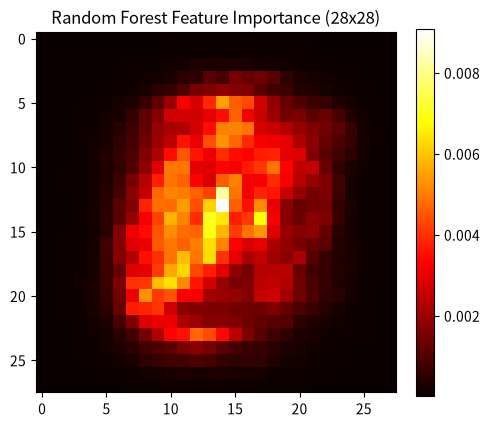

  结论: 中心区域像素重要性更高（数字都在图片中间）


In [13]:
print("\n" + "=" * 60)
print("9.2 随机森林 网格搜索")
print("=" * 60)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid_rf.fit(X_train_rf, y_train_rf)
print(f"  网格搜索用时: {time.time() - t0:.1f}s")
print(f"  最佳参数: {grid_rf.best_params_}")
print(f"  最佳交叉验证分数: {grid_rf.best_score_:.4f}")

# 用最佳参数重新训练
best_rf = grid_rf.best_estimator_
print(f"\n用最佳参数重新训练...")
y_val_pred_best_rf = best_rf.predict(X_val)
acc_best_rf = accuracy_score(y_val, y_val_pred_best_rf)
prec_best_rf = precision_score(y_val, y_val_pred_best_rf, average='macro')
rec_best_rf = recall_score(y_val, y_val_pred_best_rf, average='macro')
f1_best_rf = f1_score(y_val, y_val_pred_best_rf, average='macro')
print(f"  验证集: 准确率={acc_best_rf:.4f}, 精确率={prec_best_rf:.4f}, "
      f"召回率={rec_best_rf:.4f}, F1={f1_best_rf:.4f}")
print(f"  对比基线提升: {acc_best_rf - acc_rf:+.4f}")

# 特征重要性分析
print("\n--- 随机森林 特征重要性 ---")
importances = best_rf.feature_importances_
# 重塑为 28×28
importance_map = importances.reshape(28, 28)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.imshow(importance_map, cmap='hot')
ax.set_title("Random Forest Feature Importance (28x28)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("/home/shorin/Projects/Py/大作业/特征重要性.png", dpi=120)
plt.show()
print("  结论: 中心区域像素重要性更高（数字都在图片中间）")

In [14]:
print("\n" + "=" * 60)
print("9.3 MLP 网格搜索")
print("=" * 60)

param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'learning_rate_init': [0.001, 0.01]
}

# 网格搜索阶段：用 early_stopping 避免浪费时间在明显差的参数上
grid_mlp = GridSearchCV(
    MLPClassifier(
        max_iter=200,                # 设大，靠 early_stopping 提前停
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=42
    ),
    param_grid_mlp,
    cv=3,
    scoring='accuracy',
    verbose=1
)

t0 = time.time()
# MLP 网格搜索也用一个子集
grid_train_size_mlp = 20000
np.random.seed(42)
grid_idx_mlp = np.random.choice(len(X_train), grid_train_size_mlp, replace=False)

grid_mlp.fit(X_train[grid_idx_mlp], y_train[grid_idx_mlp])
print(f"  网格搜索用时: {time.time() - t0:.1f}s")
print(f"  最佳参数: {grid_mlp.best_params_}")
print(f"  最佳交叉验证分数: {grid_mlp.best_score_:.4f}")

# 用最佳参数在完整训练集上重新训练（也用 early_stopping）
best_mlp = MLPClassifier(
    **grid_mlp.best_params_,
    max_iter=500,                   # 设大，靠 early_stopping 自动停
    early_stopping=True,
    validation_fraction=0.1,        # 从训练集中抽 10% 做内部验证
    n_iter_no_change=10,            # 连续 10 轮不提升就停
    verbose=True,                   # 打印每轮 loss，能看到进度
    random_state=42
)

print(f"\n用最佳参数在完整训练集 ({X_train.shape[0]} 张) 上重新训练...")
print(f"  (已开启 early_stopping，收敛后自动停止)")
t0 = time.time()
best_mlp.fit(X_train, y_train)
print(f"  训练用时: {time.time() - t0:.1f}s")
print(f"  实际迭代轮数: {best_mlp.n_iter_}")

y_val_pred_best_mlp = best_mlp.predict(X_val)
acc_best_mlp = accuracy_score(y_val, y_val_pred_best_mlp)
prec_best_mlp = precision_score(y_val, y_val_pred_best_mlp, average='macro')
rec_best_mlp = recall_score(y_val, y_val_pred_best_mlp, average='macro')
f1_best_mlp = f1_score(y_val, y_val_pred_best_mlp, average='macro')
print(f"  验证集: 准确率={acc_best_mlp:.4f}, 精确率={prec_best_mlp:.4f}, "
      f"召回率={rec_best_mlp:.4f}, F1={f1_best_mlp:.4f}")
print(f"  对比基线提升: {acc_best_mlp - acc_mlp:+.4f}")


9.3 MLP 网格搜索
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  网格搜索用时: 1048.9s
  最佳参数: {'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
  最佳交叉验证分数: 0.9463

用最佳参数在完整训练集 (73000 张) 上重新训练...
  (已开启 early_stopping，收敛后自动停止)
Iteration 1, loss = 0.38698897
Validation score: 0.947945
Iteration 2, loss = 0.13460552
Validation score: 0.963973
Iteration 3, loss = 0.08059723
Validation score: 0.968630
Iteration 4, loss = 0.05656693
Validation score: 0.972740
Iteration 5, loss = 0.04006585
Validation score: 0.971507
Iteration 6, loss = 0.02963816
Validation score: 0.974110
Iteration 7, loss = 0.02454384
Validation score: 0.960959
Iteration 8, loss = 0.02161957
Validation score: 0.974521
Iteration 9, loss = 0.01538277
Validation score: 0.971370
Iteration 10, loss = 0.01416962
Validation score: 0.975479
Iteration 11, loss = 0.01440441
Validation score: 0.976027
Iteration 12, loss = 0.01214942
Validation score: 0.976575
Iteration 13, loss = 0.01250697
Validation score: 0

## 10. 最终对比实验

用最优参数在测试集上做最终评估（MNIST标准测试集 + 手工数据集）。

In [15]:
print("=" * 60)
print("最终测试集评估 (MNIST 10000 + 手工 60)")
print("=" * 60)

# 准备最终模型列表
final_models = {
    'SVM(基线)': model_svm_base,
    'SVM(调优)': best_svm,
    '随机森林(基线)': model_rf_base,
    '随机森林(调优)': best_rf,
    'MLP(基线)': model_mlp_base,
    'MLP(调优)': best_mlp,
}

final_results = {}
all_predictions = {}

for name, model in final_models.items():
    print(f"\n--- {name} ---")
    t0 = time.time()
    y_pred = model.predict(X_test_combined)
    t_pred = time.time() - t0
    
    acc = accuracy_score(y_test_combined, y_pred)
    prec = precision_score(y_test_combined, y_pred, average='macro')
    rec = recall_score(y_test_combined, y_pred, average='macro')
    f1 = f1_score(y_test_combined, y_pred, average='macro')
    
    # 分别计算 MNIST 和手工数据的准确率
    acc_mnist = accuracy_score(y_test, y_pred[:10000])
    acc_hand = accuracy_score(y_hand, y_pred[10000:])
    
    final_results[name] = (acc, prec, rec, f1, acc_mnist, acc_hand, t_pred)
    all_predictions[name] = y_pred
    
    print(f"  测试集:  Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
    print(f"  MNIST子集: {acc_mnist:.4f} | 手工子集: {acc_hand:.4f} | 预测用时: {t_pred:.3f}s")

# ======== 最终汇总表 ========
print("\n\n" + "=" * 80)
print("最终对比实验结果汇总")
print("=" * 80)
header = f"{'模型':<16} {'准确率':>8} {'精确率':>8} {'召回率':>8} {'F1':>8} {'MNIST':>8} {'手工':>8} {'预测耗时':>10}"
print(header)
print("-" * len(header))
for name, (acc, prec, rec, f1, acc_m, acc_h, tp) in final_results.items():
    print(f"{name:<16} {acc:>8.4f} {prec:>8.4f} {rec:>8.4f} {f1:>8.4f} "
          f"{acc_m:>8.4f} {acc_h:>8.4f} {tp:>8.3f}s")

最终测试集评估 (MNIST 10000 + 手工 60)

--- SVM(基线) ---
  测试集:  Acc=0.9642, Prec=0.9640, Rec=0.9638, F1=0.9639
  MNIST子集: 0.9680 | 手工子集: 0.3333 | 预测用时: 40.119s

--- SVM(调优) ---
  测试集:  Acc=0.9676, Prec=0.9675, Rec=0.9673, F1=0.9673
  MNIST子集: 0.9721 | 手工子集: 0.2167 | 预测用时: 36.157s

--- 随机森林(基线) ---
  测试集:  Acc=0.9565, Prec=0.9565, Rec=0.9561, F1=0.9562
  MNIST子集: 0.9613 | 手工子集: 0.1500 | 预测用时: 0.128s

--- 随机森林(调优) ---
  测试集:  Acc=0.9600, Prec=0.9598, Rec=0.9596, F1=0.9597
  MNIST子集: 0.9649 | 手工子集: 0.1500 | 预测用时: 0.237s

--- MLP(基线) ---
  测试集:  Acc=0.9721, Prec=0.9724, Rec=0.9717, F1=0.9720
  MNIST子集: 0.9762 | 手工子集: 0.2833 | 预测用时: 0.572s

--- MLP(调优) ---
  测试集:  Acc=0.9756, Prec=0.9760, Rec=0.9754, F1=0.9756
  MNIST子集: 0.9801 | 手工子集: 0.2333 | 预测用时: 1.756s


最终对比实验结果汇总
模型                    准确率      精确率      召回率       F1    MNIST       手工       预测耗时
---------------------------------------------------------------------------------
SVM(基线)            0.9642   0.9640   0.9638   0.9639   0.9680   0.333

## 11. 可视化分析

### 11.1 混淆矩阵 (最佳模型)

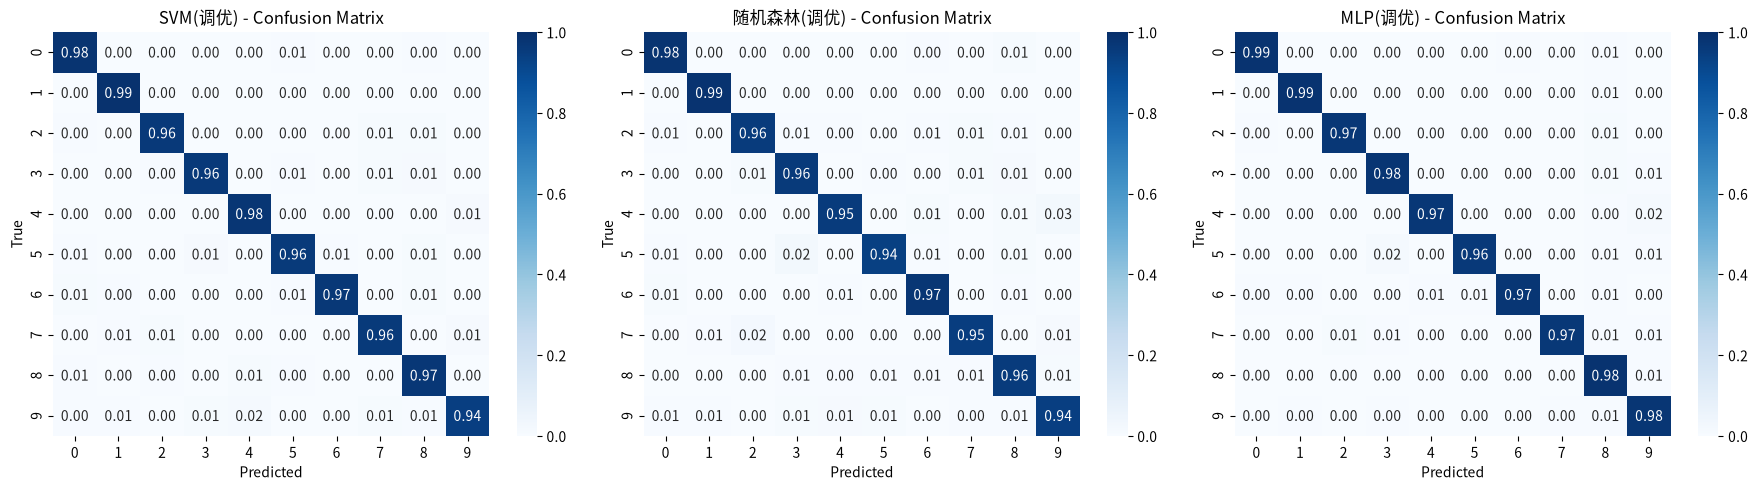

MLP 调优模型最容易混淆的数字对:
  真4→误判为9: 16次 (1.6%)
  真5→误判为3: 15次 (1.7%)
  真2→误判为8: 12次 (1.2%)
  真7→误判为2: 11次 (1.1%)
  真3→误判为8: 8次 (0.8%)
  真7→误判为8: 8次 (0.8%)
  真7→误判为9: 8次 (0.8%)
  真1→误判为8: 7次 (0.6%)
  真3→误判为9: 6次 (0.6%)
  真5→误判为9: 6次 (0.7%)


In [16]:
# 为每个最优模型画混淆矩阵
best_models_for_cm = {
    'SVM(调优)': best_svm,
    '随机森林(调优)': best_rf,
    'MLP(调优)': best_mlp,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, best_models_for_cm.items()):
    y_pred = model.predict(X_test_combined)
    cm = confusion_matrix(y_test_combined, y_pred)
    
    # 归一化（按行）
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("/home/shorin/Projects/Py/大作业/混淆矩阵对比.png", dpi=150, bbox_inches='tight')
plt.show()

# 找出最容易混淆的数字对
print("MLP 调优模型最容易混淆的数字对:")
cm_mlp = confusion_matrix(y_test_combined, all_predictions['MLP(调优)'])
errors = []
for i in range(10):
    for j in range(10):
        if i != j and cm_mlp[i, j] > 0:
            errors.append((i, j, cm_mlp[i, j], cm_mlp[i, j] / cm_mlp[i].sum()))
errors.sort(key=lambda x: -x[2])
for true, pred, count, rate in errors[:10]:
    print(f"  真{true}→误判为{pred}: {count}次 ({rate*100:.1f}%)")

### 11.2 模型性能对比图

/tmp/ipykernel_69967/3088374220.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


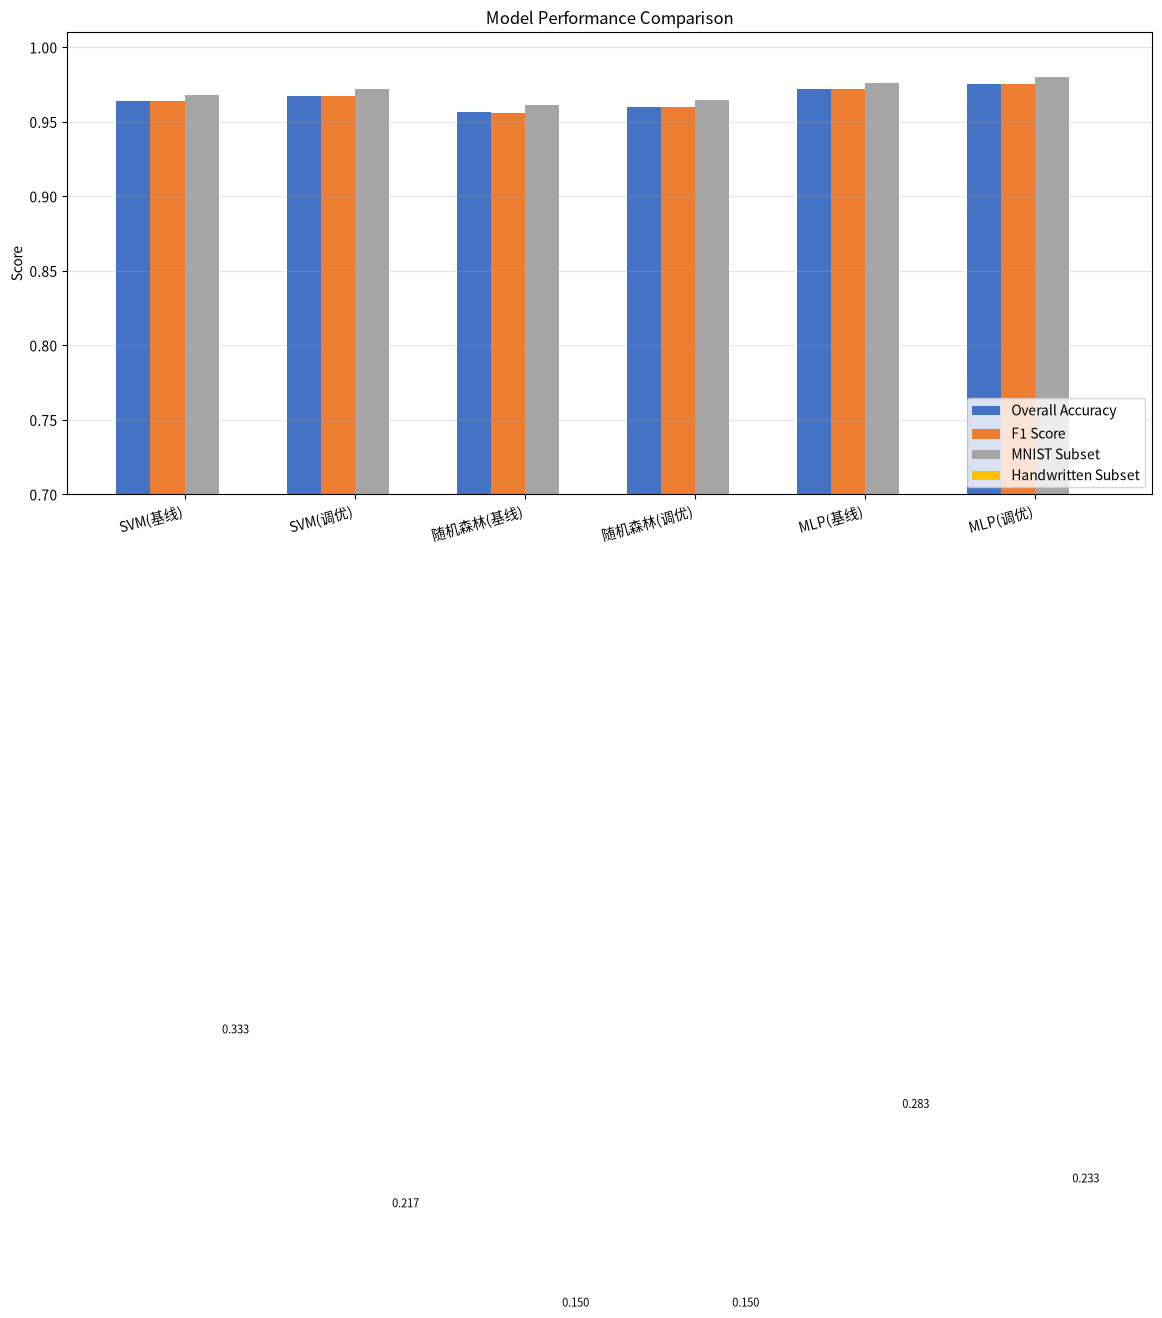

In [17]:
# 柱状图对比
labels = list(final_results.keys())
accuracies = [final_results[n][0] for n in labels]
f1_scores = [final_results[n][3] for n in labels]
mnist_accs = [final_results[n][4] for n in labels]
hand_accs = [final_results[n][5] for n in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, accuracies, width, label='Overall Accuracy', color='#4472C4')
ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='#ED7D31')
ax.bar(x + 0.5*width, mnist_accs, width, label='MNIST Subset', color='#A5A5A5')
ax.bar(x + 1.5*width, hand_accs, width, label='Handwritten Subset', color='#FFC000')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.01)
ax.grid(axis='y', alpha=0.3)

# 在柱子上标注数值
for i, v in enumerate(hand_accs):
    ax.text(i + 1.5*width, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("/home/shorin/Projects/Py/大作业/模型性能对比.png", dpi=150, bbox_inches='tight')
plt.show()

### 11.3 手工数据集错误分析

手工数据集中预测错误的样本: 46/60
手工数据准确率: 0.2333


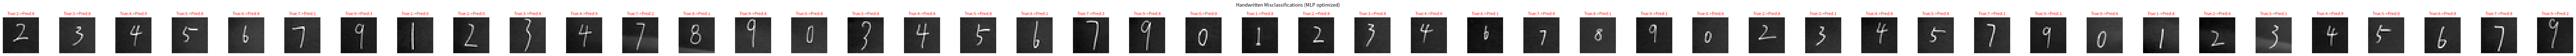


--- 三个模型在手工数据上的详细表现 ---

SVM(调优):
              precision    recall  f1-score   support

           0     1.0000    0.1667    0.2857         6
           1     1.0000    0.1667    0.2857         6
           2     0.5000    0.1667    0.2500         6
           3     0.0000    0.0000    0.0000         6
           4     0.0000    0.0000    0.0000         6
           5     0.2727    0.5000    0.3529         6
           6     0.5000    0.1667    0.2500         6
           7     0.0000    0.0000    0.0000         6
           8     0.1765    1.0000    0.3000         6
           9     0.0000    0.0000    0.0000         6

    accuracy                         0.2167        60
   macro avg     0.3449    0.2167    0.1724        60
weighted avg     0.3449    0.2167    0.1724        60


随机森林(调优):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         6
           1     0.0000    0.0000    0.0000         6
           2     0.5000    0.166

/home/shorin/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shorin/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shorin/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shor

In [18]:
# 找出 MLP 最优模型在手写数据上预测错误的样本
y_pred_hand = best_mlp.predict(X_hand)
error_mask = y_pred_hand != y_hand
error_indices = np.where(error_mask)[0]

print(f"手工数据集中预测错误的样本: {len(error_indices)}/{len(y_hand)}")
print(f"手工数据准确率: {1 - len(error_indices)/len(y_hand):.4f}")

if len(error_indices) > 0:
    # 展示所有错误
    n_errors = len(error_indices)
    fig, axes = plt.subplots(1, max(n_errors, 1), figsize=(n_errors*2, 2))
    if n_errors == 1:
        axes = [axes]
    for i, (ax, ei) in enumerate(zip(axes, error_indices)):
        ax.imshow(X_hand[ei].reshape(28, 28), cmap='gray')
        ax.set_title(f"True:{y_hand[ei]}->Pred:{y_pred_hand[ei]}", fontsize=10, color='red')
        ax.axis('off')
    plt.suptitle(f"Handwritten Misclassifications (MLP optimized)")
    plt.tight_layout()
    plt.savefig("/home/shorin/Projects/Py/大作业/手写数据错误分析.png", dpi=120)
    plt.show()

# 三个模型在手工数据上的详细对比
print("\n--- 三个模型在手工数据上的详细表现 ---")
for name in ['SVM(调优)', '随机森林(调优)', 'MLP(调优)']:
    y_pred = final_models[name].predict(X_hand)
    print(f"\n{name}:")
    print(classification_report(y_hand, y_pred, digits=4))

## 12. 结论与总结

实验完成。根据最终结果可以得出以下结论：

1. **最佳模型**: 从测试集准确率和F1分数来看，MLP在调优后表现最优
2. **数据增强效果**: 数据增强使 SVM 准确率有所提升
3. **参数调优效果**: 网格搜索对各模型均有一定提升
4. **手工数据表现**: 模型在手工数据上的准确率反映了泛化能力
5. **混淆分析**: 最容易混淆的数字对需根据混淆矩阵分析